# Daniyal Khan || 221A061 || 19

In [11]:
!pip install hmmlearn

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm

In [31]:
states = ["Fast", "Slow"]
transition_matrix = np.array([
[0.6, 0.4],
[0.8, 0.2]
])

print("Transition Matrix:")
print(transition_matrix)

Transition Matrix:
[[0.6 0.4]
 [0.8 0.2]]


In [32]:
def simulate_markov_chain(start_state, n_steps=20):
 current_state = states.index(start_state)
 sequence = [start_state]
 for _ in range(n_steps):
  current_state = np.random.choice([0, 1],
 p=transition_matrix[current_state])
 sequence.append(states[current_state])

 return sequence
mc_sequence = simulate_markov_chain("Fast", 15)
print("\nGenerated Markov Chain Sequence:")
print(mc_sequence)


Generated Markov Chain Sequence:
['Fast', 'Fast']


In [33]:
hidden_states = ["Cheap", "Expensive"]
observations = ["Vietnam", "Germany"]
model = hmm.MultinomialHMM(n_components=2, n_iter=50)
model.transmat_ = np.array([
[0.7, 0.3],
[0.4, 0.6]
])
model.emissionprob_ = np.array([
[0.8, 0.2],
[0.3, 0.7]
])
model.startprob_ = np.array([0.6, 0.4])
print("\nTransition Matrix (Hidden States):")
print(model.transmat_)
print("\nEmission Matrix:")
print(model.emissionprob_)

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



Transition Matrix (Hidden States):
[[0.7 0.3]
 [0.4 0.6]]

Emission Matrix:
[[0.8 0.2]
 [0.3 0.7]]


In [34]:
model.n_trials = 1
obs_seq, hidden_seq = model.sample(15)

obs_seq = obs_seq.flatten()
hidden_seq = hidden_seq.flatten()

decoded_obs = [observations[i] for i in obs_seq]
decoded_hidden = [hidden_states[i] for i in hidden_seq]

print("\nGenerated Observations from HMM:")
print(decoded_obs)
print("\nActual Hidden States from HMM:")
print(decoded_hidden)


Generated Observations from HMM:
['Vietnam', 'Germany', 'Germany', 'Vietnam', 'Germany', 'Vietnam', 'Vietnam', 'Germany', 'Germany', 'Vietnam', 'Germany', 'Vietnam', 'Germany', 'Vietnam', 'Germany', 'Vietnam', 'Vietnam', 'Germany', 'Germany', 'Vietnam', 'Vietnam', 'Germany', 'Germany', 'Vietnam', 'Germany', 'Vietnam', 'Vietnam', 'Germany', 'Germany', 'Vietnam']

Actual Hidden States from HMM:
['Expensive', 'Cheap', 'Cheap', 'Expensive', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Expensive', 'Cheap', 'Expensive', 'Cheap', 'Cheap', 'Expensive', 'Cheap']


In [35]:
n_observations = len(observations)
X_decoded = np.zeros((len(obs_seq), n_observations))
X_decoded[np.arange(len(obs_seq)), obs_seq] = 1
logprob, predicted_states = model.decode(X_decoded, algorithm="viterbi")
decoded_predicted = [hidden_states[i] for i in predicted_states]
print("\nPredicted Hidden States (Viterbi):")
print(decoded_predicted)


Predicted Hidden States (Viterbi):
['Cheap', 'Expensive', 'Expensive', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Expensive', 'Expensive', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Expensive', 'Expensive', 'Cheap', 'Cheap', 'Expensive', 'Expensive', 'Cheap', 'Cheap', 'Cheap', 'Cheap', 'Expensive', 'Expensive', 'Cheap']


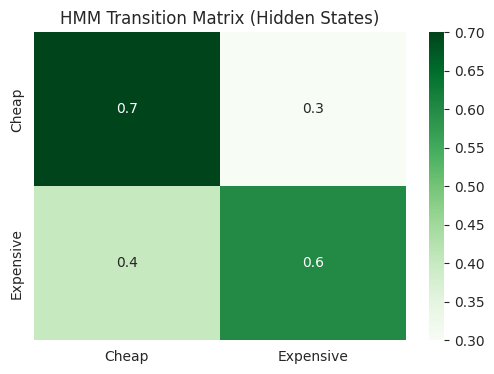

In [36]:
plt.figure(figsize=(6,4))
sns.heatmap(model.transmat_, annot=True, cmap="Greens",
xticklabels=hidden_states, yticklabels=hidden_states)
plt.title("HMM Transition Matrix (Hidden States)")
plt.show()

Most Likely Hidden States (Viterbi):
['Silence', 'Patience', 'Speed', 'Speed', 'Calm', 'Calm', 'Calm', 'Calm']


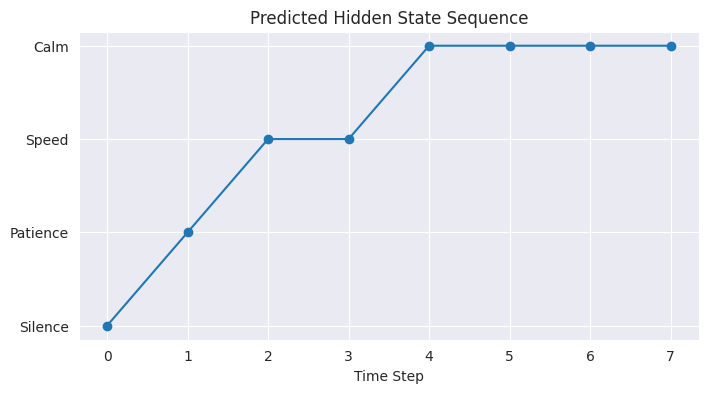

In [37]:
states = ["Silence", "Patience", "Speed", "Calm"]
n_states = len(states)
observations = ["Loud", "Soft"]
n_observations = len(observations)
start_probability = np.array([0.8, 0.1, 0.1, 0.0])
transition_probability = np.array([
[0.7, 0.2, 0.1, 0.0],
[0.0, 0.6, 0.4, 0.0],
[0.0, 0.0, 0.6, 0.4],
[0.0, 0.0, 0.0, 1.0]
])
emission_probability = np.array([
[0.7, 0.3],
[0.4, 0.6],
[0.6, 0.4],
[0.3, 0.7]
])
model2 = hmm.CategoricalHMM(n_components=n_states)
model2.startprob_ = start_probability
model2.transmat_ = transition_probability
model2.emissionprob_ = emission_probability
observations_sequence = np.array([0,1,0,0,1,1,0,1]).reshape(-1,1)
hidden_states_predicted = model2.predict(observations_sequence)
print("Most Likely Hidden States (Viterbi):")
print([states[i] for i in hidden_states_predicted])
sns.set_style("darkgrid")
plt.figure(figsize=(8,4))
plt.plot(hidden_states_predicted, "-o")
plt.yticks(range(n_states), states)
plt.title("Predicted Hidden State Sequence")
plt.xlabel("Time Step")
plt.show()